# EDA 03 (Bureau Balance)

Tercer EDA de la Fase 2. `bureau_balance` es el panel mensual de cada crédito reportado al buró
(`SK_ID_BUREAU`, `MONTHS_BALANCE`, `STATUS`), hijo de `bureau`. Cierra la rama del buró: mientras
`bureau` da una foto agregada de la mora, esta tabla da su **trayectoria mes a mes**, así que la
pregunta que guía el análisis es cuánta señal *incremental* aporta sobre lo que ya extraje de
`bureau` y de los `EXT_SOURCE`.

Sigue el esqueleto de dos fases (nivel fila con TARGET heredado → nivel cliente agregado con control
de composición). Como no tiene `SK_ID_CURR` ni TARGET propio, el enlace es triple
(`bureau_balance` → `bureau` → `application_train`) y la agregación es doble
(`SK_ID_BUREAU` → `SK_ID_CURR`). El EDA no modifica datos: investiga, clasifica y deja decisiones
para la Fase 3.

## Síntesis ejecutiva

*(TL;DR para lectura rápida; las cifras salen del ranking consolidado de la sección 11.)*

**Cobertura, la primera sorpresa.** Solo **92.231 clientes de train (29,99%)** tienen histórico
mensual, frente al 85,69% que tenían historial en `bureau`. Y **`HAS_BUREAU_BALANCE` no discrimina**:
8,14% de default con balance vs 8,04% sin él (+0,10pp, p=0,35). Al contrario que `HAS_BUREAU_HISTORY`
(−2,39pp), aquí la *presencia* del dato no es señal — la disponibilidad del panel mensual depende del
buró que reporta, no del riesgo del cliente. Esto obliga a condicionar toda la Fase B a
`HAS_BUREAU_BALANCE` (control de composición) desde el inicio.

**Dónde vive la señal: la mora reciente.** El valor de esta tabla no es tener DPD alguna vez, sino
**cuándo**. `BB_RECENT_DPD_FLAG` (DPD en los últimos 6 meses) rinde **+4,89pp** condicionado, el
delta más alto del bloque, y la recencia del último impago traza un gradiente monótono limpio: de
7,54% (último DPD hace 24+ meses) a **13,20%** (en los últimos 3 meses). Es exactamente lo que el
snapshot de `bureau` no podía ver.

**Complementa, no duplica, a `bureau`.** `BB_ANY_DPD_FLAG` vs `BUREAU_OVERDUE_UNION` da V de Cramér
0,3945 (moderada, < 0,50): rescata **16.000 clientes** con DPD mensual que la mora agregada de
`bureau` no marcaba. La señal DPD solapa parcialmente con `EXT_SOURCE_3` (|r| ≤ 0,32, ninguna supera
0,70) → conservar, pero medir IV incremental sobre `EXT_SOURCE_3` en Fase 3.

**Descarte por redundancia estructural.** La continua de mayor rank-biserial crudo, `BB_MONTHS_MAX`
(0,1502), es longitud de historial y correlaciona **−0,7451 con `BUREAU_DAYS_CREDIT_MIN`** (> 0,70):
se descarta pese a la señal, igual que se descartó `BUREAU_DAYS_ENDDATE_FACT_MIN` en `bureau`. La
señal cruda más alta no siempre entra.

**Entran (a validar con IV sobre el split en Fase 3):** `BB_RECENT_DPD_FLAG`, `BB_ANY_DPD_FLAG`,
`BB_MONTHS_SINCE_LAST_DPD`, `BB_STATUS_WORST`, `BB_DPD_MONTHS_COUNT`/`BB_PCT_MONTHS_DPD`,
`BB_WRITEOFF_FLAG`. **Descartan:** `HAS_BUREAU_BALANCE` (sin señal), `BB_MONTHS_MAX`/`BB_MONTHS_TOTAL`
(redundancia con `bureau`), `BB_N_CREDITS_WBAL` (ruido). Los descartes por señal son **provisionales**
(medidos sobre train completo, reconfirmar sobre el split); el de `BB_MONTHS_MAX` es
target-independiente y firme.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, mannwhitneyu, norm

sys.path.insert(0, str(Path.cwd().parent))
from src.data.loader import load_table, verify_dtypes
from src.features.eval import EvaluadorSenal

# paleta global del proyecto
C_NODEF, C_DEF = "steelblue", "crimson"
C_NULL, C_PARC, C_PRES = "orange", "gold", "mediumseagreen"
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 110

### 1. Carga

Perfil, integridad por código y el enlace triple. `bureau_balance` no tiene `SK_ID_CURR` y para llegar
al TARGET tengo que pasar por `bureau`
(`SK_ID_BUREAU` - `SK_ID_CURR`) y luego por `application_train`.

Antes de cualquier cruce verifico la
integridad por código (unicidad del par crédito-mes, duplicados de fila) y la cobertura triple:
cuántos créditos del panel están realmente en `bureau`, y a cuántos clientes de train llego.

In [2]:
bb = load_table("bureau_balance")
bureau = load_table("bureau")
train = load_table("application_train")

print("bureau_balance:", bb.shape, "|", round(bb.memory_usage(deep=True).sum()/1024**2, 1), "MB")
print(bb.dtypes.to_dict())
bb.head()

bureau_balance: (27299925, 3) | 156.2 MB
{'SK_ID_BUREAU': dtype('uint32'), 'MONTHS_BALANCE': dtype('int8'), 'STATUS': CategoricalDtype(categories=['0', '1', '2', '3', '4', '5', 'C', 'X'], ordered=False, categories_dtype=object)}


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [3]:
# la unicidad del par (SK_ID_BUREAU, MONTHS_BALANCE) implica la unicidad de la fila completa
n_dup_row = int(bb.duplicated().sum())
assert not bb.duplicated(subset=["SK_ID_BUREAU", "MONTHS_BALANCE"]).any(), "par crédito-mes no único"
print(f"filas: {len(bb):,} | SK_ID_BUREAU únicos: {bb['SK_ID_BUREAU'].nunique():,}")
print(f"Integridad: par (SK_ID_BUREAU, MONTHS_BALANCE) único | duplicados de fila completa: {n_dup_row}")
print(f"nulos literales por columna: {bb.isnull().sum().to_dict()}")  # 0 en las 3: la ausencia se codifica como STATUS='X' (ver seccion 5)

filas: 27,299,925 | SK_ID_BUREAU únicos: 817,395
Integridad: par (SK_ID_BUREAU, MONTHS_BALANCE) único | duplicados de fila completa: 0
nulos literales por columna: {'SK_ID_BUREAU': 0, 'MONTHS_BALANCE': 0, 'STATUS': 0}


In [4]:
# cobertura triple
bb_ids     = set(bb["SK_ID_BUREAU"])
bureau_ids = set(bureau["SK_ID_BUREAU"])
train_ids  = set(train["SK_ID_CURR"])

inter = bb_ids & bureau_ids
bureau_train = bureau[bureau["SK_ID_CURR"].isin(train_ids)]

# cliente (materializa el enlace triple); solo créditos presentes en bureau
# SK_ID_BUREAU es PK en bureau
map_bc = bureau_train[bureau_train["SK_ID_BUREAU"].isin(inter)][["SK_ID_BUREAU", "SK_ID_CURR"]]

n_bb, n_inter, n_bureau, n_train = len(bb_ids), len(inter), len(bureau_ids), len(train_ids)
n_cb, n_cbb = bureau_train["SK_ID_CURR"].nunique(), map_bc["SK_ID_CURR"].nunique()

print(f"SK_ID_BUREAU en balance -> {n_bb:,}")
print(f"  de ellos, en bureau -> {n_inter:,}")
print(f"  huérfanos (no en bureau) -> {n_bb - n_inter:,}  -> se pierden al cruzar con TARGET")
print(f"% de créditos de bureau con panel mensual: {n_inter / n_bureau * 100:.2f}%\n")
print(f"clientes de train con historial bureau -> {n_cb:,}  ({n_cb / n_train * 100:.2f}%)")
print(f"clientes de train con panel mensual -> {n_cbb:,}  ({n_cbb / n_train * 100:.2f}%)")


SK_ID_BUREAU en balance -> 817,395
  de ellos, en bureau -> 774,354
  huérfanos (no en bureau) -> 43,041  -> se pierden al cruzar con TARGET
% de créditos de bureau con panel mensual: 45.11%

clientes de train con historial bureau -> 263,491  (85.69%)
clientes de train con panel mensual -> 92,231  (29.99%)


La tabla tiene 27.299.925 filas y 3 columnas (156,2 MB tras `reduce_mem_usage`), sin un solo
duplicado de fila ni del par `(SK_ID_BUREAU, MONTHS_BALANCE)`: cada fila es un crédito-mes único,
como esperaba. Hay 817.395 créditos con histórico mensual.

La cobertura es lo primero que me impacta y tiene consecuencias. Solo el **45,11%** de los créditos de `bureau` tiene panel mensual, y **43.041 `SK_ID_BUREAU`** del balance NO existen en `bureau`: son huérfanos que se pierden al cruzar con el `TARGET` (SIN `bureau` NO hay `SK_ID_CURR`).

A nivel cliente: de los 263.491 clientes de train con historial en `bureau` (85,69%), solo **92.231 (29,99%) tienen histórico mensual**. Es un tercio del dataset, MUY por debajo de la cobertura de
`bureau`.

Esto me anticipa que `HAS_BUREAU_BALANCE` medirá disponibilidad de reporte del buró, pero NO necesariamente riesgo, y que el control de composición (condicionar a tener panel) tendrá que ser obligatorio en la Fase B (como en el notebook 02).

### 2. Distribución variable objetivo (`BB_MONTHS_COUNT`) + cruce con `TARGET`

La variable marco es la longitud del panel: el número de meses observados por crédito (`MONTHS_BALANCE`
va de 0 a −96, un máximo de 97 meses ≈ 8 años). Antes de agregar miro su distribución y su relación
con el riesgo a nivel cliente (longitud máxima de panel), con la cautela de que "más historial" puede
ser simplemente redundante con la antigüedad que ya capturé en `bureau`.

count    817395.0
mean         33.4
std          25.8
min           1.0
1%            2.0
5%            4.0
50%          26.0
95%          90.0
99%          97.0
max          97.0
dtype: float64


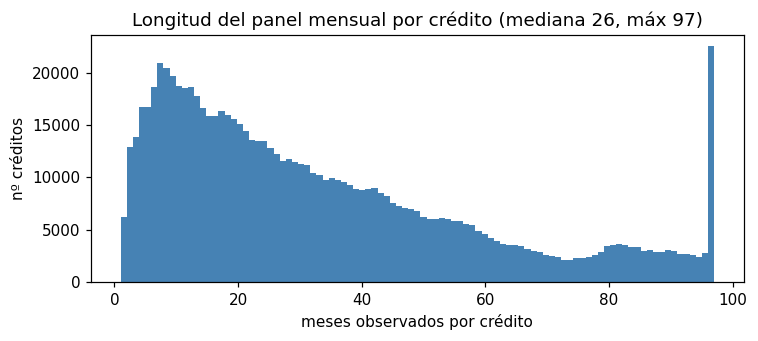

In [5]:
meses_credito = bb.groupby("SK_ID_BUREAU").size()
print(meses_credito.describe(percentiles=[.01, .05, .5, .95, .99]).round(1))

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(meses_credito, bins=97, color=C_NODEF)
ax.set_xlabel("meses observados por crédito"); ax.set_ylabel("nº créditos")
ax.set_title("Longitud del panel mensual por crédito (mediana 26, máx 97)")
plt.tight_layout(); plt.show()

In [6]:
# longitud máxima de panel por cliente vs default (teaser; el descarte se formaliza en la sección 10)
credit_mc = bb.groupby("SK_ID_BUREAU").size().rename("mc").reset_index().merge(map_bc, on="SK_ID_BUREAU")
cli_mmax = credit_mc.groupby("SK_ID_CURR")["mc"].max().rename("BB_MONTHS_MAX")
m2 = train[["SK_ID_CURR", "TARGET"]].merge(cli_mmax, on="SK_ID_CURR", how="inner")
m2["bin"] = pd.cut(m2["BB_MONTHS_MAX"], [0, 12, 24, 48, 97])
tab = m2.groupby("bin", observed=True)["TARGET"].agg(tasa="mean", n="size")
tab["tasa"] = (tab["tasa"]*100).round(2)
print(tab)
print("mediana meses (TARGET=0):", m2.loc[m2.TARGET==0,'BB_MONTHS_MAX'].median(),
      "| (TARGET=1):", m2.loc[m2.TARGET==1,'BB_MONTHS_MAX'].median())

           tasa      n
bin                   
(0, 12]   11.85  11866
(12, 24]  10.20  14911
(24, 48]   7.91  27573
(48, 97]   6.34  37881
mediana meses (TARGET=0): 42.0 | (TARGET=1): 33.0


La longitud del panel es asimétrica: mediana 26 meses, media 33,4, con una acumulación en el
tope de 97 meses (créditos seguidos desde el inicio de la ventana del buró) y otra en paneles muy
cortos. A nivel cliente, la longitud máxima de panel traza un gradiente monótono claro: de 11,85%
de default en clientes cuyo crédito más largo no llega a 12 meses, a 6,34% en los que superan 48
meses; los no-defaulters tienen paneles más largos (mediana 42 vs 33 meses).

La lectura es la misma que en `bureau` con la longitud de historial: más recorrido observable =
cliente más establecido = menor riesgo. Pero precisamente por eso sospecho **redundancia con
`bureau`**, no señal nueva. Lo verifico formalmente en la sección 10 (spoiler: Pearson −0,75 con
`BUREAU_DAYS_CREDIT_MIN`, se descarta). Aquí queda planteada la hipótesis; el descarte llega con el
test.

### 3. Verificación dtypes / Clasificación variables

Solo tres columnas: un identificador (`SK_ID_BUREAU`), una temporal (`MONTHS_BALANCE`) y una
categórica ordinal-con-matices (`STATUS`). El interés está en `STATUS`, cuyo tratamiento no es un
simple `category`: mezcla una escala ordinal de mora (0–5) con dos códigos fuera de escala (`C`, `X`)
que analizo en las secciones 4 y 5.

In [7]:
display(verify_dtypes("bureau_balance", bb))
print("\nSTATUS es categórica con orden parcial: 0<1<2<3<4<5 (DPD), más C (cerrado) y X (sin info).")

,Variable,Tipo Actual,Categoría Esperada,Estado,Detalle
0,SK_ID_BUREAU,uint32,ID,OK,
1,MONTHS_BALANCE,int8,Days/Time,OK,
2,STATUS,category,Categorical,OK,



STATUS es categórica con orden parcial: 0<1<2<3<4<5 (DPD), más C (cerrado) y X (sin info).


### 4. Análisis distribuciones variables

`STATUS` codifica el estado de mora de cada crédito-mes: `0` sin retraso, `1`–`5` en tramos de
días de impago (DPD: 1=1–30d, … 5=120+d o fallido), `C` crédito cerrado/saldado y `X` sin
información ese mes. Es la estructura tripartita conocida (§8.4 del proyecto): `X` es ausencia de
dato, `C` es "saldado", y `0`–`5` es severidad ordinal. La decisión de encoding se plantea aquí y se
resuelve en la Fase B.

In [8]:
# higiene de categóricas: verificar typos/espacios/caso aunque salga limpio
crudo = bb["STATUS"].astype(str)
print("nunique crudo vs strip+upper:", crudo.nunique(), "vs", crudo.str.strip().str.upper().nunique())

vc = bb["STATUS"].value_counts()
pct = (vc/len(bb)*100).round(3)
print(pd.DataFrame({"n": vc, "%": pct}))
print("\nDPD real (1-5):", f"{vc[['1','2','3','4','5']].sum():,}", f"({pct[['1','2','3','4','5']].sum():.2f}%)")

nunique crudo vs strip+upper: 8 vs 8
               n       %
STATUS                  
C       13646993  49.989
0        7499507  27.471
X        5810482  21.284
1         242347   0.888
5          62406   0.229
2          23419   0.086
3           8924   0.033
4           5847   0.021

DPD real (1-5): 342,943 (1.26%)


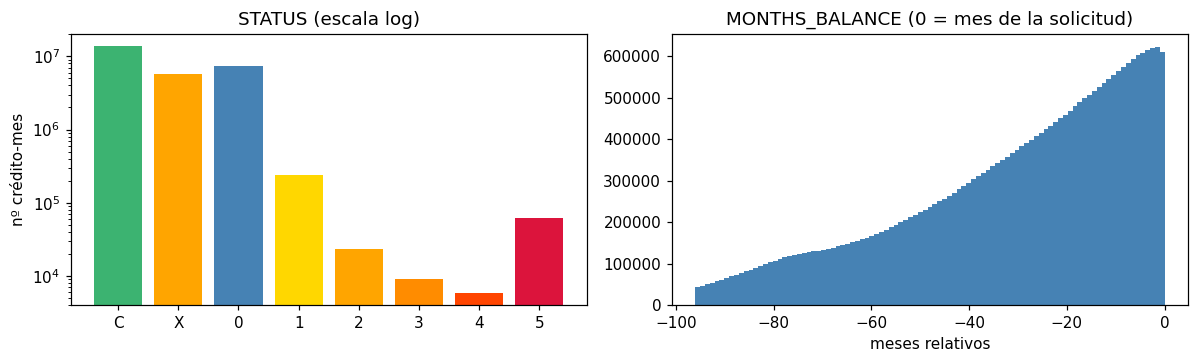

MONTHS_BALANCE: min -96 máx 0 | meses > 0: 0


In [9]:
orden = ["C", "X", "0", "1", "2", "3", "4", "5"]
cols  = [C_PRES, C_NULL, C_NODEF, "gold", "orange", "darkorange", "orangered", C_DEF]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].bar(orden, [vc[s] for s in orden], color=cols)
ax[0].set_yscale("log"); ax[0].set_title("STATUS (escala log)"); ax[0].set_ylabel("nº crédito-mes")
ax[1].hist(bb["MONTHS_BALANCE"], bins=97, color=C_NODEF)
ax[1].set_title("MONTHS_BALANCE (0 = mes de la solicitud)"); ax[1].set_xlabel("meses relativos")
plt.tight_layout(); plt.show()
print("MONTHS_BALANCE: min", bb['MONTHS_BALANCE'].min(), "máx", bb['MONTHS_BALANCE'].max(),
      "| meses > 0:", (bb['MONTHS_BALANCE']>0).sum())

`STATUS` está limpio (8 categorías, sin typos ni espacios: `strip().upper()` no cambia la
cardinalidad). Domina `C` (49,99%, créditos cerrados) y `0` (27,47%, activos sin mora). Lo llamativo
es **`X` con 21,28%**: uno de cada cinco crédito-mes no reporta estado. La mora real (`1`–`5`) es
apenas el **1,26%** del panel, con la severidad cayendo en cascada (`1` 0,89% → `5` 0,23% → `4`
0,02%): los impagos son eventos raros y los graves aún más, así que la señal —igual que en la mora
de `bureau`— vivirá en la cola, no en el centro.

`MONTHS_BALANCE` es un dominio cerrado y coherente: de −96 a 0, sin ningún valor positivo (ningún mes
posterior a la solicitud, como debe ser). Esto simplifica la sección de outliers: no hay error de
rango temporal que corregir.

Decisión de encoding que se traslada a la Fase B: mapear `0`–`5` a una escala ordinal de DPD, tratar
`C` y `X` **fuera de esa escala** (no son 0 ni 6). `X` se analiza como el eje de missing de esta
tabla en la sección 5; `C` es información positiva (crédito saldado).

### 5. Análisis Missings

El eje de missing de esta tabla es `X` (sin información ese mes): ¿la ausencia de reporte discrimina?
`X` no es un `NaN` literal pero es su equivalente semántico: "sin información ese mes". Con un 21,28%
del panel merece el tratamiento de un missing. Dos preguntas: ¿la frecuencia de `X` se asocia al
default?, ¿su aparición depende del tiempo (más `X` en meses antiguos, como el deterioro de reporte
que vi en `bureau`)?

In [10]:
# merge triple para heredar TARGET a nivel fila
tgt = train[["SK_ID_CURR", "TARGET"]]
bb_t = bb.merge(map_bc, on="SK_ID_BUREAU", how="inner").merge(tgt, on="SK_ID_CURR", how="inner")
print("filas con TARGET heredado:", f"{len(bb_t):,}", "| default global:", f"{bb_t['TARGET'].mean()*100:.3f}%")

# X vs default a nivel crédito-mes
s = bb_t["STATUS"].astype(str)
for etiqueta, mask in [("X (sin info)", s=='X'), ("C (cerrado)", s=='C'), ("0 (activo sin mora)", s=='0')]:
    print(f"  {etiqueta:22s}: default {bb_t.loc[mask,'TARGET'].mean()*100:.2f}%  (n={mask.sum():,})")

filas con TARGET heredado: 14,701,612 | default global: 6.940%


  X (sin info)          : default 6.96%  (n=2,837,039)
  C (cerrado)           : default 6.39%  (n=7,027,575)
  0 (activo sin mora)   : default 7.59%  (n=4,615,684)


In [11]:
# patrón temporal de X: ¿más ausencia de reporte en meses antiguos?
bb["_isX"] = (bb["STATUS"].astype(str) == "X")
bb["_antig"] = pd.cut(bb["MONTHS_BALANCE"], [-97, -60, -36, -12, 0],
                      labels=["60m+", "36-60m", "12-36m", "0-12m"])
pctX = bb.groupby("_antig", observed=True)["_isX"].mean().mul(100).round(2)
print("% de meses en X por antigüedad:\n", pctX)

% de meses en X por antigüedad:
 _antig
60m+      26.87
36-60m    21.65
12-36m    20.29
0-12m     19.28
Name: _isX, dtype: float64


`X` **no marca riesgo, marca lo contrario de forma leve**: 6,96% de default en los crédito-mes
con `X`, por debajo del 7,59% de `0` y cerca del 6,39% de `C`. Tiene sentido — un crédito que el buró
deja de reportar suele ser uno inactivo o ya resuelto, más parecido a un cerrado que a uno con mora
viva. No es un missing informativo de riesgo; es ruido administrativo.

El patrón temporal lo confirma: la proporción de `X` sube monótona con la antigüedad, de 17,77% en
el último año a 23,97% más allá de 60 meses. Es el mismo deterioro de reporte que observé en
`bureau` (la completitud se degrada con la edad del crédito): cuanto más viejo el mes, más probable
que el buró no tenga estado. Consecuencia para la Fase B: al medir "% de meses en mora" hay que
normalizar por meses **con estado reportado** (`0`–`5`), no por el total de meses, para que el `X`
inflado de los créditos antiguos no diluya el denominador. Por lo demás, `X` no genera feature de
riesgo propia.

### 6. Análisis Correlaciones

Señal a nivel fila y jerarquía de riesgo por `STATUS`. Con el TARGET heredado, ordeno la tasa de
default por cada valor de `STATUS`. Es una medición a nivel
crédito-mes (pseudoreplicada: los ~14,7M meses cuelgan de 92.231 clientes que comparten TARGET), así
que la leo como *jerarquía cualitativa*, no como magnitud de efecto — esa la fijo a nivel cliente en
la Fase B.

In [12]:
tab = bb_t.groupby(bb_t["STATUS"].astype(str))["TARGET"].agg(tasa="mean", n="size")
tab["tasa"] = (tab["tasa"]*100).round(2)
tab = tab.reindex(["C", "X", "0", "1", "2", "3", "4", "5"])
display(tab)

# Chi2 + V de Cramér de STATUS vs TARGET (nivel fila)
ct = pd.crosstab(bb_t["STATUS"].astype(str), bb_t["TARGET"])
chi2, p, _, _ = chi2_contingency(ct)
V = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
print(f"Chi2 = {chi2:,.0f}  p = {p:.2e}  V de Cramér = {V:.4f}")

,tasa,n
STATUS,,
C,6.39,7027575
X,6.96,2837039
0,7.59,4615684
1,10.24,155330
2,10.40,15583
3,11.33,5976
4,11.98,3897
5,11.39,40528


Chi2 = 10,753  p = 0.00e+00  V de Cramér = 0.0270


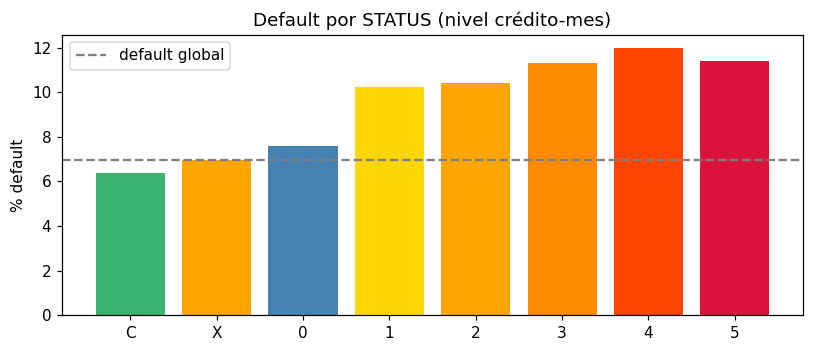

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 3.3))
orden = ["C", "X", "0", "1", "2", "3", "4", "5"]
barcol = [C_PRES, C_NULL, C_NODEF, "gold", "orange", "darkorange", "orangered", C_DEF]
ax.bar(orden, [tab.loc[s, "tasa"] for s in orden], color=barcol)
ax.axhline(bb_t["TARGET"].mean()*100, ls="--", c="gray", label="default global")
ax.set_ylabel("% default"); ax.set_title("Default por STATUS (nivel crédito-mes)")
ax.legend(); plt.tight_layout(); plt.show()

La jerarquía es nítida y ordena tres bloques. El extremo protector son los estados sin mora
viva: `C` (6,39%, crédito saldado, el más bajo) y `X` (6,96%, sin reporte). En medio, `0` (7,59%,
activo al corriente), en torno a la base. Y el salto lo dan los tramos de DPD: `1` 10,24%, y de ahí
para arriba todos por encima del 10% (`4` llega a 11,98%). Cualquier mes en mora, incluso el tramo
más leve (1–30 días), multiplica el riesgo respecto a estar al corriente.

La severidad dentro de la mora **no es perfectamente monótona** (`4` > `5` > `3` > `2` > `1`), pero
los tramos altos tienen `n` pequeñísimos (`4` con 3.897 crédito-mes) y la diferencia entre ellos cae
dentro del ruido; lo robusto es el escalón `0`→`1`. El Chi2 es grande pero la V de Cramér es 0,03
(efecto global pequeño): coherente con que el 98,7% del panel está en C/X/0 pegado a la base y solo el 1,3%
en mora concentra la señal —el mismo patrón de "Chi2 grande, V pequeña" de `bureau`. La conclusión
operativa: binarizar en "algún mes en DPD sí/no" captura casi todo; la escala fina 1–5 aporta poco
salvo el `5` (fallido) como flag aparte.

### 7. Análisis Temporal

La recencia de la mora es lo que importa. Aquí está la hipótesis central: si `bureau` ya me dice *si* hubo mora, lo que `bureau_balance` añade
es *cuándo*. Un impago de hace 3 meses no pesa lo mismo que uno de hace 4 años. Mido, sobre los
clientes que tuvieron algún DPD, la tasa de default según la recencia de su último mes en mora.

         tasa      n
bin                 
24m+     7.54  10113
12-24m   9.30   5594
6-12m    9.85   4640
3-6m    11.40   3387
0-3m    13.20   7318


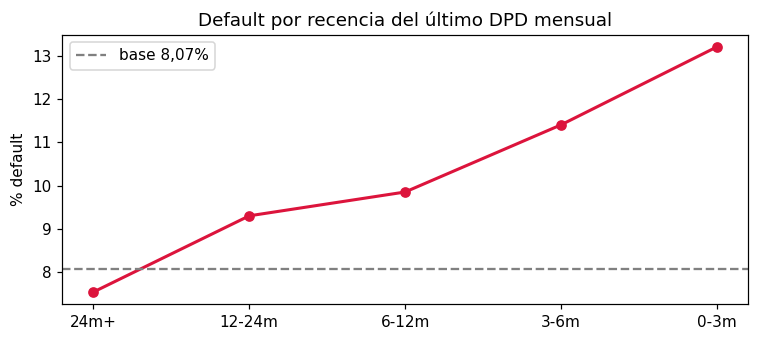

In [14]:
# recencia del último DPD por cliente (se reusa el pipeline completo de la sección 10)
s = bb_t["STATUS"].astype(str)
bb_t["_dpd"] = s.isin(["1","2","3","4","5"])
last_dpd = bb_t[bb_t["_dpd"]].groupby("SK_ID_CURR")["MONTHS_BALANCE"].max()  # más cercano a 0 = reciente
rec = train[["SK_ID_CURR","TARGET"]].merge(last_dpd.rename("last"), on="SK_ID_CURR", how="inner")
rec["bin"] = pd.cut(rec["last"], [-97, -24, -12, -6, -3, 0],
                    labels=["24m+", "12-24m", "6-12m", "3-6m", "0-3m"])
tab = rec.groupby("bin", observed=True)["TARGET"].agg(tasa="mean", n="size")
tab["tasa"] = (tab["tasa"]*100).round(2)
print(tab)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(tab.index.astype(str), tab["tasa"], "o-", color=C_DEF, lw=2)
ax.axhline(train["TARGET"].mean()*100, ls="--", c="gray", label="base 8,07%")
ax.set_ylabel("% default"); ax.set_title("Default por recencia del último DPD mensual")
ax.legend(); plt.tight_layout(); plt.show()

El gradiente es monótono y fuerte, y es el mejor argumento del notebook. Entre los clientes que
tuvieron algún DPD, la tasa de default sube de **7,54%** cuando el último impago fue hace más de 24
meses —apenas por debajo de la base de 8,07%, es decir, una mora vieja ya "perdonada"— hasta
**13,20%** cuando fue en los últimos 3 meses. Un span de +5,66pp explicado solo por la recencia.

Esto valida la razón de ser de la tabla. `bureau` da la foto agregada de la mora (tuvo/no tuvo, cuánto
importe); `bureau_balance` da la **línea de tiempo**, y la línea de tiempo dice que la mora reciente
es un predictor mucho más afilado que la mora antigua. De aquí salen las dos features temporales de la
Fase B: `BB_MONTHS_SINCE_LAST_DPD` (continua) y `BB_RECENT_DPD_FLAG` (binaria, DPD en ≤6 meses), que
resultará el flag más fuerte del bloque. Conecta con el perfil "deudor con mora activa" que ya emergió
en `bureau`, ahora con resolución temporal.

### 8. Análisis de Outliers

Validez de dominio y pseudoreplicación: `bureau_balance` casi no tiene outliers clásicos: `STATUS` es un conjunto discreto de 8 códigos y
`MONTHS_BALANCE` vive en un rango cerrado [−96, 0]. El chequeo de validez de dominio es corto, y el
punto metodológico importante es la **pseudoreplicación** que arrastra toda la Fase A.

In [15]:
# validez de dominio: rango temporal y paneles anómalos
print("MONTHS_BALANCE fuera de [-96, 0]:", ((bb['MONTHS_BALANCE'] < -96) | (bb['MONTHS_BALANCE'] > 0)).sum())
print("STATUS fuera del dominio {C,X,0-5}:",
      (~bb['STATUS'].astype(str).isin(['C','X','0','1','2','3','4','5'])).sum())
# vectorizado: un crédito es 100% X si no tiene ningún estado distinto de X
n_no_X = (bb["STATUS"].astype(str) != "X").groupby(bb["SK_ID_BUREAU"]).sum()
solo_X = (n_no_X == 0)
print("créditos con panel 100% X (sin ningún estado real):", f"{solo_X.sum():,}",
      f"({solo_X.mean()*100:.2f}% de los créditos)")

MONTHS_BALANCE fuera de [-96, 0]: 0


STATUS fuera del dominio {C,X,0-5}: 0


créditos con panel 100% X (sin ningún estado real): 85,569 (10.47% de los créditos)


No hay ni un valor de `MONTHS_BALANCE` fuera de rango ni un `STATUS` fuera del dominio: el dato
es limpio en validez, no hay error de captura que revertir en Fase 3. Los créditos con panel 100% `X`
existen pero no son error —son créditos que el buró nunca detalló—; se tratan como "sin estado
informativo" y no contaminan las features de mora porque el mapeo DPD los deja en `NaN`.

El punto que sí condiciona la lectura de toda la Fase A es la **pseudoreplicación**: los ~14,7M
crédito-mes con TARGET no son independientes, cuelgan de 92.231 clientes que comparten su etiqueta
(un cliente con panel largo aporta decenas de filas idénticas en TARGET). Esto hace los p-valores de
nivel fila anticonservadores —cualquier cosa sale significativa por volumen— y por eso las decisiones
no se apoyan en el p-valor de fila, sino en el **effect size** y, sobre todo, en la **revalidación a
nivel cliente** de la Fase B. Toda cifra de las secciones 6 y 7 es orientativa hasta reconfirmarse
agregada.

### 9. Fase B: Agregación (nivel cliente)

Cierro la Fase A (nivel fila, TARGET heredado) y arranco la Fase B. La agregación es doble porque el
TARGET vive a nivel `SK_ID_CURR` y el dato a nivel crédito-mes:

**Paso 1 — `SK_ID_BUREAU` (panel mensual → resumen por crédito):** de cada crédito resumo su historia
en `months_count` (longitud), `dpd_max` (peor tramo 0–5, `NaN` si nunca reportó estado), `any_dpd`
(tocó mora alguna vez), `dpd_months` (nº de meses en mora), `writeoff` (llegó a `5`), y
`last_dpd_month` (mes más reciente en mora, recencia).

**Paso 2 — `SK_ID_CURR` (resumen por crédito → por cliente):** uniendo el mapa `SK_ID_BUREAU →
SK_ID_CURR` de `bureau`, consolido por cliente: peor estado entre créditos, nº de créditos con mora,
recencia global del último DPD, total de meses observados, % de meses en mora, etc.

**Flag de presencia `HAS_BUREAU_BALANCE`** para el control de composición (§8.5): el `left join` a los
307.511 de train deja a `NaN` (luego `fillna(0)`) a los que no tienen panel, y como su riesgo base
(8,04%) difiere del de los que sí (8,14%), toda feature se mide **condicionada** a tener balance, no
solo global. Cada feature pasa por `EvaluadorSenal` (string = auto-condicionada por `notna()`; flag
con la máscara `has` = condicionada explícita).

### 10. Exploratorio y validación por bloques (TARGET real)

Ejecuto los dos pasos, cruzo con el TARGET real y mido cada feature con control de composición. Luego
el cruce inter-tabla obligatorio: cuánto de esta señal es nueva respecto a `bureau` y a
`EXT_SOURCE_3`.

In [16]:
# PASO 1 — nivel crédito
dpd_map = {"0": 0, "1": 1, "2": 2, "3": 3, "4": 4, "5": 5}
s = bb["STATUS"].astype(str)
bb["DPD"]    = s.map(dpd_map)            # NaN para C / X
bb["IS_DPD"] = bb["DPD"] >= 1
bb["IS_WO"]  = bb["DPD"] == 5
bb_link = bb.merge(map_bc, on="SK_ID_BUREAU", how="inner")   # solo enlazable a train

g = bb_link.groupby("SK_ID_BUREAU")
credit = pd.DataFrame({
    "SK_ID_CURR":   g["SK_ID_CURR"].first(),
    "months_count": g.size(),
    "dpd_max":      g["DPD"].max(),
    "any_dpd":      g["IS_DPD"].max().astype(bool),
    "dpd_months":   g["IS_DPD"].sum(),
    "writeoff":     g["IS_WO"].max().astype(bool),
})
credit["last_dpd_month"] = bb_link[bb_link["IS_DPD"]].groupby("SK_ID_BUREAU")["MONTHS_BALANCE"].max()
print("créditos resumidos:", f"{len(credit):,}")

créditos resumidos: 523,515


In [17]:
# PASO 2 — nivel cliente
gc = credit.groupby("SK_ID_CURR")
cli = pd.DataFrame({
    "BB_N_CREDITS_WBAL":         gc.size(),
    "BB_MONTHS_TOTAL":           gc["months_count"].sum(),
    "BB_MONTHS_MAX":             gc["months_count"].max(),
    "BB_STATUS_WORST":           gc["dpd_max"].max(),
    "BB_ANY_DPD_FLAG":           gc["any_dpd"].max().astype(int),
    "BB_DPD_MONTHS_COUNT":       gc["dpd_months"].sum(),
    "BB_WRITEOFF_FLAG":          gc["writeoff"].max().astype(int),
    "BB_CREDITS_WITH_DPD_COUNT": gc["any_dpd"].sum(),
    "BB_MONTHS_SINCE_LAST_DPD":  gc["last_dpd_month"].max(),
})
cli["BB_PCT_MONTHS_DPD"]  = gc["dpd_months"].sum() / gc["months_count"].sum() * 100
cli["BB_RECENT_DPD_FLAG"] = ((cli["BB_MONTHS_SINCE_LAST_DPD"] >= -6) & cli["BB_MONTHS_SINCE_LAST_DPD"].notna()).astype(int)

df = train[["SK_ID_CURR", "TARGET"]].merge(cli, on="SK_ID_CURR", how="left")
df["HAS_BUREAU_BALANCE"] = df["BB_N_CREDITS_WBAL"].notna().astype(int)
has = df["HAS_BUREAU_BALANCE"].values.astype(bool)

# integridad de la agregación
assert len(df) == len(train), "el left join cambió el nº de clientes"
assert has.sum() == n_cbb, "clientes con balance no cuadra con la cobertura de la sección 1"
print("clientes con balance:", has.sum(),
      "| default con:", f"{df.loc[has,'TARGET'].mean()*100:.2f}%",
      "| sin:", f"{df.loc[~has,'TARGET'].mean()*100:.2f}%",
      "| base:", f"{df['TARGET'].mean()*100:.3f}%")

clientes con balance: 92231 | default con: 8.14% | sin: 8.04% | base: 8.073%


In [18]:
TARGET = df["TARGET"].values
ev = EvaluadorSenal(df, TARGET)

for c in ["BB_ANY_DPD_FLAG", "BB_WRITEOFF_FLAG", "BB_RECENT_DPD_FLAG"]:
    df[c] = df[c].fillna(0)

print("FLAGS (HAS_BUREAU_BALANCE global; el resto condicionado a tener balance)")
ev.evaluar_flags([
    ("HAS_BUREAU_BALANCE",  df["HAS_BUREAU_BALANCE"].values),
    ("BB_ANY_DPD_FLAG",     df["BB_ANY_DPD_FLAG"].values,     has),
    ("BB_WRITEOFF_FLAG",    df["BB_WRITEOFF_FLAG"].values,    has),
    ("BB_RECENT_DPD_FLAG",  df["BB_RECENT_DPD_FLAG"].values,  has),
])

FLAGS (HAS_BUREAU_BALANCE global; el resto condicionado a tener balance)


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
HAS_BUREAU_BALANCE,global (nulo=0),8.14% (n=92231),8.04% (n=215280),+0.10 pp,0.9,0.3529435513429273
BB_ANY_DPD_FLAG,con historial,9.96% (n=31052),7.22% (n=61179),+2.74 pp,14.4,9.491117769601136e-47
BB_WRITEOFF_FLAG,con historial,11.02% (n=2206),8.07% (n=90025),+2.94 pp,5.0,5.921177452609878e-07
BB_RECENT_DPD_FLAG,con historial,12.42% (n=11602),7.53% (n=80629),+4.89 pp,18.0,1.3846285031535888e-72


In [19]:
print("CONTINUAS (auto-condicionadas por notna)")
ev.evaluar_continuas([
    "BB_MONTHS_MAX", "BB_MONTHS_SINCE_LAST_DPD", "BB_MONTHS_TOTAL", "BB_PCT_MONTHS_DPD",
    "BB_DPD_MONTHS_COUNT", "BB_CREDITS_WITH_DPD_COUNT", "BB_STATUS_WORST", "BB_N_CREDITS_WBAL",
])

CONTINUAS (auto-condicionadas por notna)


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
BB_MONTHS_MAX,no nulos (auto-cond.),92231,0.1502,1.7192923132680968e-103,42.0,33.0
BB_MONTHS_SINCE_LAST_DPD,no nulos (auto-cond.),31052,0.1379,1.7047293850946652e-36,-12.0,-8.0
BB_MONTHS_TOTAL,no nulos (auto-cond.),92231,0.1151,1.4357799188106676e-61,112.0,87.0
BB_PCT_MONTHS_DPD,no nulos (auto-cond.),92231,0.102,4.547802414897391e-68,0.0,0.0
BB_DPD_MONTHS_COUNT,no nulos (auto-cond.),92231,0.0867,9.600822421475577e-50,0.0,0.0
BB_CREDITS_WITH_DPD_COUNT,no nulos (auto-cond.),92231,0.0854,1.4447199059457173e-48,0.0,0.0
BB_STATUS_WORST,no nulos (auto-cond.),89856,0.0823,1.6901544185968016e-44,0.0,0.0
BB_N_CREDITS_WBAL,no nulos (auto-cond.),92231,0.0058,0.3980821489127381,5.0,4.0


In [20]:
# estructura tripartita: sin balance / balance sin DPD / con DPD
grp = np.where(~has, "sin_balance", np.where(df["BB_ANY_DPD_FLAG"] == 1, "con_dpd", "balance_sin_dpd"))
trip = pd.Series(TARGET).groupby(grp).agg(tasa="mean", n="size")
trip["tasa"] = (trip["tasa"]*100).round(2)
print(trip.reindex(["sin_balance", "balance_sin_dpd", "con_dpd"]))
print("\ncon_dpd vs balance_sin_dpd:",
      f"{(trip.loc['con_dpd','tasa'] - trip.loc['balance_sin_dpd','tasa']):+.2f} pp")

                 tasa       n
sin_balance      8.04  215280
balance_sin_dpd  7.22   61179
con_dpd          9.96   31052

con_dpd vs balance_sin_dpd: +2.74 pp


In [21]:
# CRUCE INTER-TABLA con bureau (nivel cliente, solo clientes con balance)
b = bureau_train.copy()
b["ov"] = ((b["AMT_CREDIT_MAX_OVERDUE"] > 0) | (b["AMT_CREDIT_SUM_OVERDUE"] > 0) | (b["CREDIT_DAY_OVERDUE"] > 0)).astype(int)
bcli = b.groupby("SK_ID_CURR").agg(BUREAU_OVERDUE_UNION=("ov", "max"),
                                   BUREAU_CURRENT_OVERDUE_SUM=("AMT_CREDIT_SUM_OVERDUE", "sum"))
dfx = df.merge(bcli, on="SK_ID_CURR", how="left")
sub = dfx[has]

ct = pd.crosstab(sub["BB_ANY_DPD_FLAG"], sub["BUREAU_OVERDUE_UNION"].fillna(0))
chi2, _, _, _ = chi2_contingency(ct)
V = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
inter = ((sub["BB_ANY_DPD_FLAG"] == 1) & (sub["BUREAU_OVERDUE_UNION"].fillna(0) == 1)).sum()
union = ((sub["BB_ANY_DPD_FLAG"] == 1) | (sub["BUREAU_OVERDUE_UNION"].fillna(0) == 1)).sum()
print("BB_ANY_DPD_FLAG vs BUREAU_OVERDUE_UNION -> V de Cramér", round(V, 4), "| Jaccard", round(inter/union, 4))
print(ct)
print("\nrescatados por bureau_balance (DPD mensual sin overdue en bureau):",
      f"{ct.loc[1, 0.0]:,}")
print("Pearson BB_STATUS_WORST vs BUREAU_CURRENT_OVERDUE_SUM:",
      round(sub[["BB_STATUS_WORST", "BUREAU_CURRENT_OVERDUE_SUM"]].corr().iloc[0, 1], 4))

BB_ANY_DPD_FLAG vs BUREAU_OVERDUE_UNION -> V de Cramér 0.3945 | Jaccard 0.3889
BUREAU_OVERDUE_UNION    0.0    1.0
BB_ANY_DPD_FLAG                   
0.0                   53526   7653
1.0                   16000  15052

rescatados por bureau_balance (DPD mensual sin overdue en bureau): 16,000
Pearson BB_STATUS_WORST vs BUREAU_CURRENT_OVERDUE_SUM: 0.0199


In [22]:
# CRUCE con EXT_SOURCE_3 (score de buró) + redundancia estructural de BB_MONTHS_MAX
ext = train[["SK_ID_CURR", "EXT_SOURCE_3"]]
dbm = bureau_train.groupby("SK_ID_CURR").agg(BUREAU_DAYS_CREDIT_MIN=("DAYS_CREDIT", "min"))
sub2 = df.merge(ext, on="SK_ID_CURR", how="left").merge(dbm, on="SK_ID_CURR", how="left")[has]

print("Correlación con EXT_SOURCE_3 (ninguna supera 0,70 -> se conservan, medir IV incremental en Fase 3):")
for c in ["BB_MONTHS_SINCE_LAST_DPD", "BB_ANY_DPD_FLAG", "BB_STATUS_WORST", "BB_DPD_MONTHS_COUNT", "BB_MONTHS_TOTAL"]:
    print(f"  {c:26s} {sub2[[c,'EXT_SOURCE_3']].corr().iloc[0,1]:+.4f}")

r_mm = sub2[["BB_MONTHS_MAX", "BUREAU_DAYS_CREDIT_MIN"]].corr().iloc[0, 1]
print(f"\nBB_MONTHS_MAX vs BUREAU_DAYS_CREDIT_MIN: Pearson {r_mm:+.4f}",
      "-> REDUNDANTE (>0,70)" if abs(r_mm) > 0.70 else "")

Correlación con EXT_SOURCE_3 (ninguna supera 0,70 -> se conservan, medir IV incremental en Fase 3):
  BB_MONTHS_SINCE_LAST_DPD   -0.3150
  BB_ANY_DPD_FLAG            -0.2351
  BB_STATUS_WORST            -0.1874
  BB_DPD_MONTHS_COUNT        -0.1366
  BB_MONTHS_TOTAL            +0.0008

BB_MONTHS_MAX vs BUREAU_DAYS_CREDIT_MIN: Pearson -0.7451 -> REDUNDANTE (>0,70)


**Presencia** `HAS_BUREAU_BALANCE` no es señal: da +0,10pp (8,14% vs 8,04%, p=0,35, no
significativo). Al revés que `HAS_BUREAU_HISTORY` (−2,39pp), tener panel mensual no dice nada del
riesgo, porque quién tiene panel lo decide el buró que reporta, no el cliente. Confirma la necesidad
del control de composición y descarta la feature de presencia como predictor.

**Mora y recencia** La partición tripartita es limpia y monótona: sin balance
8,04% (n=215.280) → balance sin DPD 7,22% (n=61.179, el más protector) → con DPD 9,96% (n=31.052),
un contraste con-DPD vs sin-DPD de **+2,74pp**. Entre las flags condicionadas, `BB_RECENT_DPD_FLAG`
lidera con **+4,89pp** (n=11.602), muy por encima de `BB_WRITEOFF_FLAG` (+2,94pp, n=2.206) y
`BB_ANY_DPD_FLAG` (+2,74pp): otra vez, la mora reciente pesa más que la mora grave o la mora a secas.

**Valor incremental frente a `bureau`** `BB_ANY_DPD_FLAG` vs `BUREAU_OVERDUE_UNION` da V de Cramér
0,3945 (moderada, por debajo del umbral 0,50 de redundancia) y Jaccard 0,39: se solapan en 15.052
clientes pero `bureau_balance` **rescata 16.000** con DPD mensual que la mora agregada de `bureau` no
marcaba (y `bureau` aporta otros 7.653 que el panel no ve). Son dos ventanas distintas al mismo
fenómeno. Y `BB_STATUS_WORST` vs `BUREAU_CURRENT_OVERDUE_SUM` da Pearson 0,02: prácticamente
ortogonales. El valor incremental sobre `bureau` es real.

**Valor incremental frente a `EXT_SOURCE`** La señal DPD correlaciona con el score de buró
(`BB_MONTHS_SINCE_LAST_DPD` −0,32, `BB_ANY_DPD_FLAG` −0,24, `BB_STATUS_WORST` −0,19) pero ninguna
supera 0,70: se conservan, con la obligación de medir su **IV incremental sobre `EXT_SOURCE_3`** en
Fase 3, no darla por buena en aislamiento.

**Redundancia estructural** `BB_MONTHS_MAX`, la continua de mayor rank-biserial crudo (0,1502),
correlaciona **−0,7451 con `BUREAU_DAYS_CREDIT_MIN`**: supera el umbral de multicolinealidad, mide lo
mismo (longitud/antigüedad de historial) y por tanto se descarta pese a la señal —igual criterio que
`BUREAU_DAYS_ENDDATE_FACT_MIN` en `bureau`. `BB_MONTHS_TOTAL` (−0,60) queda en la misma sospecha,
como secundaria. `BB_N_CREDITS_WBAL` (r_rb 0,006, p=0,40) es ruido. La señal cruda más alta no siempre
entra: hay que restarle lo que ya está en otra tabla.

### 11. Fase B: Conclusiones y features candidatas para FE

Consolido cada feature con su población de medición, efecto y estado (decisión para Fase 3), y
exporto la receta a `config/bureau_balance_features.yaml` con el mismo patrón que `bureau`.

In [23]:
ranking = pd.DataFrame(ev.fb_flags + ev.fb_cont)
ranking = ranking.sort_values("efecto", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

estado = {
    "BB_RECENT_DPD_FLAG":        "conservar (mora reciente, top flag)",
    "BB_MONTHS_MAX":             "descartar (redundancia bureau r=-0.75)",
    "BB_MONTHS_SINCE_LAST_DPD":  "conservar (recencia continua)",
    "BB_MONTHS_TOTAL":           "descartar (redundancia bureau r=-0.60)",
    "BB_WRITEOFF_FLAG":          "conservar (fallido, flag)",
    "BB_ANY_DPD_FLAG":           "conservar (mora, complementa bureau)",
    "BB_PCT_MONTHS_DPD":         "conservar (intensidad de mora)",
    "BB_DPD_MONTHS_COUNT":       "IV (intensidad, correlada con PCT)",
    "BB_CREDITS_WITH_DPD_COUNT": "IV (secundaria)",
    "BB_STATUS_WORST":           "conservar (severidad)",
    "HAS_BUREAU_BALANCE":        "descartar (sin señal, p=0.35)",
    "BB_N_CREDITS_WBAL":         "descartar (ruido, p=0.40)",
}
ranking["estado"] = ranking["feature"].map(estado)
ranking["efecto"] = ranking["efecto"].round(4)
display(ranking[["feature", "tipo", "poblacion", "efecto", "n_pos", "estado"]])

# Bonferroni sobre la familia de comparaciones válidas (una por feature)
print("comparaciones emitidas (familia Bonferroni de referencia):", len(ev.fb_comparisons))

,feature,tipo,poblacion,efecto,n_pos,estado
0,BB_RECENT_DPD_FLAG,flag,con historial,4.8932,11602,"conservar (mora reciente, top flag)"
1,BB_WRITEOFF_FLAG,flag,con historial,2.9432,2206,"conservar (fallido, flag)"
2,BB_ANY_DPD_FLAG,flag,con historial,2.7361,31052,"conservar (mora, complementa bureau)"
3,BB_MONTHS_MAX,continua,no nulos (auto-cond.),0.1502,92231,descartar (redundancia bureau r=-0.75)
4,BB_MONTHS_SINCE_LAST_DPD,continua,no nulos (auto-cond.),0.1379,31052,conservar (recencia continua)
5,BB_MONTHS_TOTAL,continua,no nulos (auto-cond.),0.1151,92231,descartar (redundancia bureau r=-0.60)
6,BB_PCT_MONTHS_DPD,continua,no nulos (auto-cond.),0.1020,92231,conservar (intensidad de mora)
7,HAS_BUREAU_BALANCE,flag,global (nulo=0),0.0996,92231,"descartar (sin señal, p=0.35)"
8,BB_DPD_MONTHS_COUNT,continua,no nulos (auto-cond.),0.0867,92231,"IV (intensidad, correlada con PCT)"
9,BB_CREDITS_WITH_DPD_COUNT,continua,no nulos (auto-cond.),0.0854,92231,IV (secundaria)


comparaciones emitidas (familia Bonferroni de referencia): 12


In [24]:
import yaml

agg = {
    "BB_RECENT_DPD_FLAG":        "max(mes en DPD dentro de los últimos 6 meses)",
    "BB_ANY_DPD_FLAG":           "max(algún mes STATUS in 1-5)",
    "BB_WRITEOFF_FLAG":          "max(algún mes STATUS==5)",
    "BB_MONTHS_SINCE_LAST_DPD":  "max(MONTHS_BALANCE de meses en DPD) = recencia",
    "BB_STATUS_WORST":           "max(DPD 0-5 sobre créditos)",
    "BB_PCT_MONTHS_DPD":         "sum(meses DPD)/sum(meses reportados)*100",
    "BB_DPD_MONTHS_COUNT":       "sum(meses en DPD)",
    "BB_CREDITS_WITH_DPD_COUNT": "count(créditos con algún DPD)",
    "BB_MONTHS_MAX":             "max(longitud de panel por crédito)",
    "BB_MONTHS_TOTAL":           "sum(meses observados)",
    "BB_N_CREDITS_WBAL":         "count(créditos con panel)",
    "HAS_BUREAU_BALANCE":        "flag: cliente con panel mensual",
}
receta = {
    "tabla": "bureau_balance",
    "nivel": "SK_ID_CURR (doble agregación SK_ID_BUREAU -> SK_ID_CURR)",
    "nota": ("enlace triple vía bureau; cobertura 29,99% de train. Cruces con TARGET sobre train "
             "completo, recalcular IV sobre el split en FE. Descartes por señal provisionales; "
             "el de BB_MONTHS_MAX/TOTAL es redundancia estructural con bureau (firme)."),
    "features": {},
}
for _, r in ranking.iterrows():
    f = r["feature"]
    receta["features"][f] = {
        "tipo": r["tipo"], "agregacion": agg.get(f, ""),
        "poblacion_medicion": r["poblacion"], "efecto": float(round(r["efecto"], 4)),
        "estado": estado.get(f, ""),
    }

out = Path.cwd().parent / "config" / "bureau_balance_features.yaml"
out.write_text(yaml.safe_dump(receta, sort_keys=False, allow_unicode=True))
print("exportado:", out)
print(out.read_text()[:600])

exportado: /Users/yeraybc/proyectos/Home-Credit-Default-Risk/config/bureau_balance_features.yaml
tabla: bureau_balance
nivel: SK_ID_CURR (doble agregación SK_ID_BUREAU -> SK_ID_CURR)
nota: enlace triple vía bureau; cobertura 29,99% de train. Cruces con TARGET sobre
  train completo, recalcular IV sobre el split en FE. Descartes por señal provisionales;
  el de BB_MONTHS_MAX/TOTAL es redundancia estructural con bureau (firme).
features:
  BB_RECENT_DPD_FLAG:
    tipo: flag
    agregacion: max(mes en DPD dentro de los últimos 6 meses)
    poblacion_medicion: con historial
    efecto: 4.8932
    estado: conservar (mora reciente, top flag)
  BB_WRITEOFF_FLAG:
    tipo: flag
    agregacion: ma


`bureau_balance` cierra la rama del buró y su aportación se puede resumir en una frase: **añade la
dimensión temporal de la mora que el snapshot de `bureau` no tenía**. Reviso las decisiones por
grupos.

**Presencia (descartada).** `HAS_BUREAU_BALANCE` no discrimina (+0,10pp, p=0,35), a diferencia de
`HAS_BUREAU_HISTORY`. La disponibilidad del panel mensual la decide el buró, no el cliente; solo sirve
como flag de control de composición, no como predictor. La cobertura del 29,99% obliga además a que
toda la señal de esta tabla se mida condicionada.

**Mora y recencia (el núcleo, conservadas).** `BB_RECENT_DPD_FLAG` (+4,89pp) es la feature estrella:
la mora en los últimos 6 meses casi dobla la tasa base. La acompañan `BB_MONTHS_SINCE_LAST_DPD`
(recencia continua, gradiente 7,54%→13,20%), `BB_ANY_DPD_FLAG` (+2,74pp), `BB_STATUS_WORST`
(severidad) y `BB_PCT_MONTHS_DPD` (intensidad). `BB_WRITEOFF_FLAG` (+2,94pp) marca el fallido como
evento aparte. Todas complementan a `bureau` (V de Cramér 0,39, rescatan 16.000 clientes) y solo
solapan parcialmente con `EXT_SOURCE_3` (|r| ≤ 0,32) → se conservan con test de IV incremental
obligatorio en Fase 3.

**Historial (descartadas por redundancia).** `BB_MONTHS_MAX` (r_rb 0,1502, la más alta en crudo) y
`BB_MONTHS_TOTAL` miden longitud de historial, ya capturada por `BUREAU_DAYS_CREDIT_MIN` (Pearson
−0,75 y −0,60). Es un descarte por redundancia estructural, target-independiente y firme: la señal
existe pero no es nueva.

**Ruido (descartada).** `BB_N_CREDITS_WBAL` (r_rb 0,006, p=0,40): el número de créditos con panel no
aporta nada por sí solo.

**Provisos.** Como en `bureau`, los cruces con TARGET son sobre train completo → los descartes por
señal (`HAS_BUREAU_BALANCE`, `BB_N_CREDITS_WBAL`) son provisionales y deben reconfirmarse sobre el
split en Fase 3; conservar es seguro, eliminar mirando todo el TARGET no. La pseudoreplicación de la
Fase A queda cubierta por la revalidación a nivel cliente. Y la encoding de la mora, cuando entre al
modelo, respetará la estructura tripartita (`X`/`C` fuera de la escala DPD; % de meses en mora
normalizado por meses reportados, no por total, dado el `X` creciente con la antigüedad). Con esto la
rama del buró (`bureau` + `bureau_balance`) queda cerrada; siguen las cuatro tablas de la rama
`previous_application`.